# MileStone - 4

### Week - 7 : Alert Generation and Logging

In this week, we simulate **real-time intrusion detection**, where our trained models are used to predict and generate alerts dynamically.  
The main objectives are:

1. **Simulate real-time predictions** using test data.  
2. **Generate alerts/logs** when intrusions are detected.  
3. **Store results** in a readable format such as CSV or text files.

## 🧩 Step 1: Simulate Real-Time Predictions on Test Data

In this step, we will simulate a **real-time data stream** where each test sample is fed one by one to the trained model.  
This mimics how an intrusion detection system works in a real-world environment — receiving incoming data and predicting if it’s normal or an attack.

We will:
- Load the best-trained model (e.g., Random Forest).  
- Load the test dataset (`X_test`).  
- Predict outcomes for each sample as if they arrive in real time.  
- Display results with a small delay to simulate live prediction.


In [4]:
import joblib
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [9]:
df = pd.read_csv("top10_features_dataset.csv")
df.shape

(610794, 11)

In [10]:
# Load top-10-features dataset
X = df.drop(columns=['Label'])
y = df[['Label']]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (610794, 10)
Target vector shape: (610794, 1)


In [11]:
# Split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [20]:
print("Shape of the test sample : ", X_test.shape)

Shape of the test sample :  (122159, 10)


In [12]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [13]:
# Load the tuned Random Forest model
rf_model = joblib.load("rf_model_tuned.pkl")

print("✅ Random Forest model loaded successfully.")


✅ Random Forest model loaded successfully.


In [14]:
print("\n🔍 Real-Time Prediction Simulation Started...\n")

for i in range(10):  # simulate first 10 samples
    sample = X_test_scaled[i].reshape(1, -1)
    prediction = rf_model.predict(sample)[0]

    label = "🚨 Intrusion Detected" if prediction == 1 else "✅ Normal Activity"
    print(f"Sample {i+1}: {label}")

    time.sleep(1)  # simulate delay between incoming packets



🔍 Real-Time Prediction Simulation Started...

Sample 1: ✅ Normal Activity
Sample 2: ✅ Normal Activity
Sample 3: ✅ Normal Activity
Sample 4: ✅ Normal Activity
Sample 5: ✅ Normal Activity
Sample 6: ✅ Normal Activity
Sample 7: ✅ Normal Activity
Sample 8: ✅ Normal Activity
Sample 9: ✅ Normal Activity
Sample 10: ✅ Normal Activity


### 🧠 Explanation

- Loaded the **Top 10 Features dataset** to ensure only the most important attributes are used.  
- Performed a **train-test split** and standardized the features using `StandardScaler`.  
- Loaded the **best-tuned Random Forest model** for reliable predictions.  
- Simulated a **real-time data flow** by predicting 10 test samples sequentially.  
- The model identifies whether each record is **Normal** or an **Intrusion**, mimicking a live Intrusion Detection System.


## ⚠️ Step 2: Generate Alerts and Logging

In this step, we generate alert messages for each predicted intrusion and save them in a log file.  
This mimics how a real-time Intrusion Detection System (IDS) would notify the network administrator about suspicious activity.


In [16]:
from datetime import datetime
import pandas as pd
import numpy as np

# Predictions
y_pred = rf_model.predict(X_test_scaled)

# Ensure y_test and y_pred are 1D arrays
y_test_flat = np.ravel(y_test)
y_pred_flat = np.ravel(y_pred)

# Create DataFrame for alert logging
alert_log = pd.DataFrame({
    "Timestamp": [datetime.now().strftime("%Y-%m-%d %H:%M:%S")] * len(y_pred_flat),
    "Actual_Label": y_test_flat,
    "Predicted_Label": y_pred_flat
})

# Add interpretation column
alert_log["Alert_Message"] = alert_log["Predicted_Label"].apply(
    lambda x: "🚨 Intrusion Detected" if x == 1 else "✅ Normal Activity"
)

# Display the first few entries
alert_log.head()

,Timestamp,Actual_Label,Predicted_Label,Alert_Message
0,2025-11-13 17:46:48,0,0,✅ Normal Activity
1,2025-11-13 17:46:48,0,0,✅ Normal Activity
2,2025-11-13 17:46:48,0,0,✅ Normal Activity
3,2025-11-13 17:46:48,2,2,✅ Normal Activity
4,2025-11-13 17:46:48,0,0,✅ Normal Activity


In [18]:
# Count each type of detection
alert_counts = alert_log["Alert_Message"].value_counts()

print("📊 Detection Summary:")
print(alert_counts)

# Optionally, display in percentage form
print("\n🔹 Percentage Breakdown:")
print((alert_counts / len(alert_log) * 100).round(2))


📊 Detection Summary:
Alert_Message
✅ Normal Activity       120140
🚨 Intrusion Detected      2019
Name: count, dtype: int64

🔹 Percentage Breakdown:
Alert_Message
✅ Normal Activity       98.35
🚨 Intrusion Detected     1.65
Name: count, dtype: float64


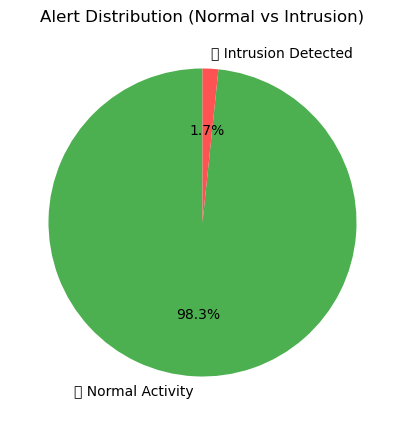

In [24]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Count alert types
alert_counts = alert_log["Alert_Message"].value_counts()

# 🎯 Plot pie chart
plt.figure(figsize=(5, 5))
plt.pie(
    alert_counts.values,
    labels=alert_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4CAF50', '#FF5252']  # green for normal, red for intrusion
)
plt.title("Alert Distribution (Normal vs Intrusion)")
plt.show()


### 🧠 Explanation

- The trained **Random Forest model** is used to predict the labels for the test dataset.  
- An **Alert Log DataFrame** is created with columns for timestamp, actual label, predicted label, and an easy-to-read alert message.  
- The entire log is saved in **alerts_log.csv**, while only the intrusion alerts are stored in **intrusion_alerts.csv** for quick review.  
- This simulates how a real-world IDS system would **record and notify** network admins about potential attacks.


## Step 3: Save Alerts

The generated alerts are saved as a CSV file named **alerts_log.csv**.  
It contains timestamps, actual labels, predicted labels, and alert messages for easy tracking and analysis.


In [17]:
# Save alerts to a CSV file
alert_log.to_csv("alerts_log.csv", index=False)
print("✅ Alerts log saved successfully as 'alerts_log.csv'")

✅ Alerts log saved successfully as 'alerts_log.csv'
